NAME:MEHTAB AHMED 023-24-0285 
BSCS SECTION H 
GITHUB:https://github.com/mehtabahmeddev/MACHINE-LEARNING/tree/f74fc4cc24f42a63618f104c63215a75dfd435e3/LAB-04
KAGGLE:https://www.kaggle.com/mehtabahmed3201

In [1]:
#task 1
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("clean_churn.csv")

y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
#task 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


best_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_test)

# Report evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.7853589196872779
Precision: 0.6111111111111112
Recall   : 0.5294117647058824
F1-score : 0.5673352435530086


In [34]:
#task 3

from sklearn.ensemble import RandomForestClassifier as RFC
model = RFC(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predictions",y_pred)


result=X_test.copy()

result["Predictions"]=y_pred
print(result)

Predictions [0 1 0 ... 0 0 0]
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
971               0      59           75.95       4542.35        False   
618               0       7           78.55        522.95        False   
4282              0      54           20.10       1079.45        False   
3715              0       2           20.65         38.70        False   
4525              0      71          105.15       7555.00        False   
...             ...     ...             ...           ...          ...   
4821              0      12           45.00        524.35        False   
5168              0      26           45.80       1147.00        False   
2745              0       3           19.45         69.25         True   
4424              0      37           40.55       1390.85         True   
2086              0      50           20.15        970.85        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
971          True         

#task4 
Random Forest usually generalizes better because it combines many decision trees and takes their combined prediction instead of relying on one tree. This reduces overfitting and makes the model more reliable on new data.


Accuracy : 0.7867803837953091
Precision: 0.6209150326797386
Recall   : 0.5080213903743316
F1-score : 0.5588235294117647


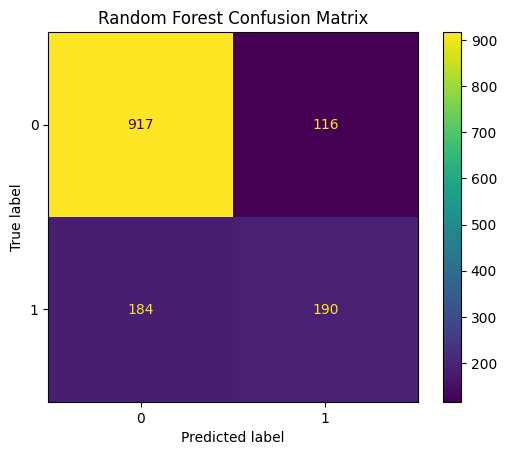

In [36]:
# Task 5

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [37]:
# Task 6

from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Decision Tree from Lab 3
dt_model = DTC(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# Decision Tree metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Comparison table
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_dt, accuracy],
    "Precision": [precision_dt, precision],
    "Recall": [recall_dt, recall],
    "F1-score": [f1_dt, f1]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1-score
0  Decision Tree  0.785359   0.611111  0.529412  0.567335
1  Random Forest  0.786780   0.620915  0.508021  0.558824


task7#Random Forest performs better than the Decision Tree if it has higher values for most of the metrics. The difference is marginal if the values are close. Since the Telco Churn dataset has class imbalance, recall is the most important metric because it shows how well the model identifies customers who actually churn.

In [38]:
# Task 8

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier as RFC


dt_model = DTC(max_depth=6, random_state=42)

dt_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring='f1'
)


rf_model = RFC(n_estimators=200, random_state=42)

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1'
)


print("DT F1 Scores:", dt_scores)
print("DT Mean:", dt_scores.mean())
print("DT Standard Deviation:", dt_scores.std())

print("\nRF F1 Scores:", rf_scores)
print("RF Mean:", rf_scores.mean())
print("RF Standard Deviation:", rf_scores.std())

DT F1 Scores: [0.58224163 0.54211332 0.54778887 0.57988166 0.5633383 ]
DT Mean: 0.5630727568574153
DT Standard Deviation: 0.01626622455474026

RF F1 Scores: [0.56661562 0.55384615 0.52880355 0.57010786 0.56621005]
RF Mean: 0.5571166446035599
RF Standard Deviation: 0.015192233728664753


#task9The cross-validation results give a more reliable view of the models because the models are tested on five different splits instead of only one split. If Random Forest has a higher mean F1-score than Decision Tree, it supports our previous conclusion that Random Forest performs better. The standard deviation also shows how consistent the model is across different folds, so cross-validation makes us more confident in the result.

In [39]:
# Task 10

from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import GridSearchCV


rf = RFC(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [45]:
#TASK11
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validated F1-score:
0.5807534519243903


In [48]:
# Task 12

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


tuned_model = grid_search.best_estimator_


y_pred_tuned = tuned_model.predict(X_test)


accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("Accuracy :", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall   :", recall_tuned)
print("F1-score :", f1_tuned)

Tuned Random Forest Results
Accuracy : 0.7889125799573561
Precision: 0.6287625418060201
Recall   : 0.5026737967914439
F1-score : 0.5586924219910847


In [49]:
# Task 13

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Default Random Forest", "Tuned Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy,
        accuracy_score(y_test, y_pred_tuned)
    ],

    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision,
        precision_score(y_test, y_pred_tuned)
    ],

    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall,
        recall_score(y_test, y_pred_tuned)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_dt),
        f1,
        f1_score(y_test, y_pred_tuned)
    ]
})

print(final_comparison)

                   Model  Accuracy  Precision    Recall  F1-score
0          Decision Tree  0.785359   0.611111  0.529412  0.567335
1  Default Random Forest  0.786780   0.620915  0.508021  0.558824
2    Tuned Random Forest  0.788913   0.628763  0.502674  0.558692


task14I selected the Decision Tree as the final model because it has the highest F1-score 0.5673 and recall 0.5294 among the three models. Recall is important because it shows how many actual customers who churn are correctly identified, while F1-score gives a balance between precision and recall. Although the Random Forest models have slightly better accuracy and precision, the Decision Tree performs better on the more important churn-related metrics.


Top 5 Important Features:
tenure                         0.182865
TotalCharges                   0.160851
MonthlyCharges                 0.124068
InternetService_Fiber optic    0.064206
Contract_Two year              0.059125
dtype: float64


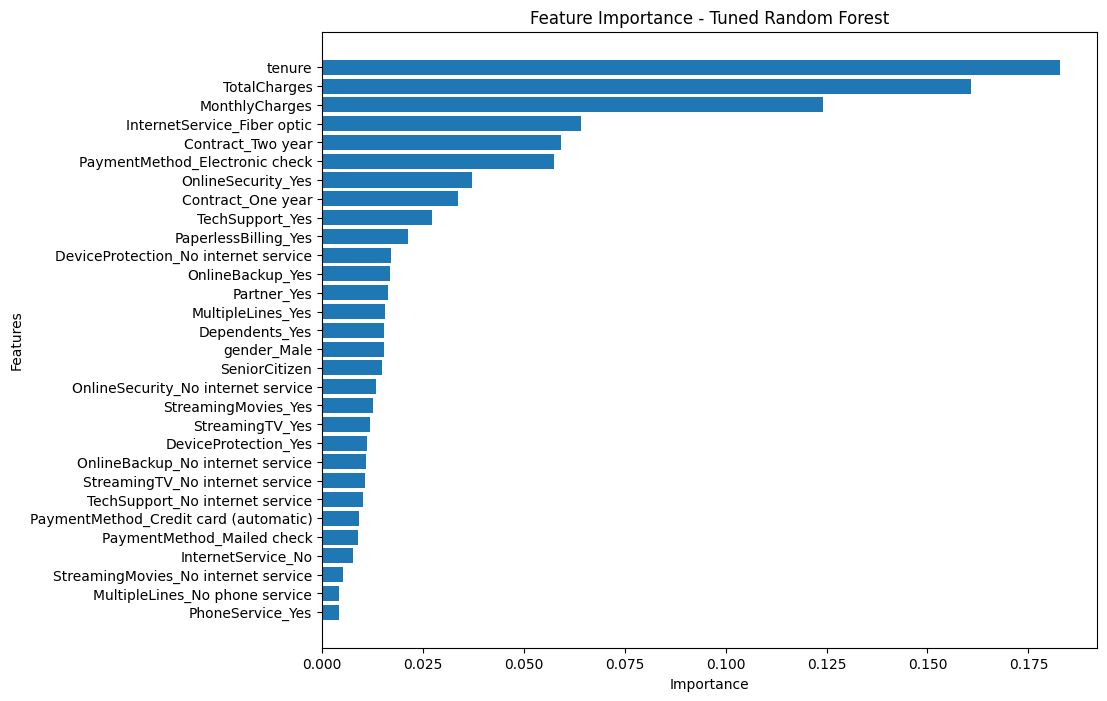

In [50]:
# Task 15

import pandas as pd
import matplotlib.pyplot as plt

# Feature importance of final model
importances = grid_search.best_estimator_.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

# Show top 5 features
print("Top 5 Important Features:")
print(feature_importance.sort_values(ascending=False).head(5))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.index, feature_importance.values)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Tuned Random Forest")
plt.show()

In [55]:
# Task 16

import pandas as pd


submission = pd.DataFrame({
    "customerID": X_test.index,
    "Churn": y_pred_dt
})

print(submission.head())

# Save as CSV
submission.to_csv("submission.csv", index=False)

   customerID  Churn
0         971      0
1         618      1
2        4282      0
3        3715      0
4        4525      0


In [54]:
print(df.columns.tolist()) ////////

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [53]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
X                  DataFrame    Shape: (7032, 30)
X_test             DataFrame    Shape: (1407, 30)
X_train            DataFrame    Shape: (5625, 30)
comparison         DataFrame    Shape: (2, 5)
df                 DataFrame    Shape: (7032, 20)
final_comparison   DataFrame    Shape: (3, 5)
result             DataFrame    Shape: (1407, 31)


task 17 In this lab, I compared a Decision Tree, Default Random Forest, and Tuned Random Forest for predicting customer churn. I selected the Decision Tree as the final model because it achieved the highest recall and F1-score, which are important for identifying customers who may churn. Compared with the Lab 3 Decision Tree, the model used in this lab gives a more balanced evaluation through comparison with Random Forest models and cross-validation. However, the final model still has limitations, especially its relatively low recall, meaning that some actual churners are still missed. The model could also be improved further to make more reliable churn predictions.


task18 If I had more time, I would try other algorithms such as Logistic Regression, XGBoost, or Gradient Boosting to see if they perform better. I would also do deeper hyperparameter tuning instead of using a small parameter grid. Since the dataset has class imbalance, I would try techniques such as class weights or resampling to improve recall for churned customers. Finally, I would compare the models using cross-validation and focus more on F1-score and recall instead of accuracy alone.
